# ForgeWM Paper 3 — Experiment 8: Boundary Characterisation

**Goal**: Empirically characterise the irreducible discovery boundary —
variables causally decoupled from all observables are undetectable,
and variables with any causal coupling are detectable.

## What we verify
The boundary proposition states:
- W is detectable ↔ P(V_obs | do(W=w)) ≠ P(V_obs) for some V_obs, w
- W is undetectable ↔ W has zero causal effect on all V_obs

We construct three classes of hidden variable:
1. **Strongly coupled** — large causal effect on observable (detectable)
2. **Weakly coupled** — small but non-zero causal effect (detectable at large n)
3. **Decoupled** — zero causal effect (irreducibly undetectable)

We measure detection rate vs coupling strength, identifying the empirical boundary.

**Expected runtime**: ~4 hours on T4

---

## Cell 1 — Install and Imports

In [6]:
import subprocess
subprocess.run('pip install -q causallearn scipy scikit-learn '
               'matplotlib numpy pandas tqdm', shell=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ks_2samp
from tqdm.notebook import tqdm
import json, warnings
warnings.filterwarnings('ignore')
print('Ready.')

Ready.


## Cell 2 — FEM Oracle with Variable Coupling Strength

In [7]:
LAMBDA_STAR = 0.002

def fem_with_hidden_W(n_samples, rng, coupling_strength, W_val=None):
    """
    FEM oracle with hidden variable W.
    coupling_strength γ ∈ [0, 1]:
      γ = 0:   W has zero causal effect on σ (irreducibly undetectable)
      γ > 0:   W causally affects σ_y (detectable at sufficient n)
      γ = 1:   W has large effect (easily detectable)

    Physical interpretation: W is a hidden microstructural parameter
    that modifies yield stress by fraction γ.
    """
    rows = []
    for _ in range(n_samples):
        E       = rng.uniform(100e9, 300e9)
        epsilon = rng.uniform(0.0005, 0.006)
        sigma_y = rng.uniform(200e6, 600e6)
        H       = rng.uniform(1e9, 50e9)

        # W: hidden microstructural variable
        W = W_val if W_val is not None else rng.uniform(0, 1)

        # Causal effect: W modifies sigma_y by ±γ·50%
        sigma_y_eff = sigma_y * (1 + coupling_strength * (W - 0.5))
        sigma_y_eff = max(sigma_y_eff, 10e6)

        if epsilon <= LAMBDA_STAR:
            sigma = E * epsilon
        else:
            sigma = sigma_y_eff + H * (epsilon - LAMBDA_STAR)

        rows.append({'E':E,'epsilon':epsilon,'sigma_y':sigma_y,
                     'H':H,'W':W,'sigma':sigma,
                     'coupling':coupling_strength})
    return pd.DataFrame(rows)

def detection_test(coupling_strength, n_samples, rng, n_test=500):
    """
    Test whether W is detectable at given coupling strength.
    Uses Theorem 11's criterion: P(σ|do(W=low)) ≠ P(σ|do(W=high))
    Returns: (detected: bool, p_value: float, effect_size: float)
    """
    # do(W=0.1) — low W
    df_low  = fem_with_hidden_W(n_test, rng, coupling_strength, W_val=0.1)
    # do(W=0.9) — high W
    df_high = fem_with_hidden_W(n_test, rng, coupling_strength, W_val=0.9)

    # Only plastic regime (where W matters)
    pl = df_low[ df_low['epsilon']  > LAMBDA_STAR]['sigma'].values
    ph = df_high[df_high['epsilon'] > LAMBDA_STAR]['sigma'].values

    if len(pl) < 10 or len(ph) < 10:
        return False, 1.0, 0.0

    _, p_ks = ks_2samp(pl, ph)
    effect  = abs(pl.mean() - ph.mean()) / (pl.std() + ph.std() + 1e-10)
    return p_ks < 0.05, float(p_ks), float(effect)

# Quick verification
rng_v = np.random.default_rng(0)
for gamma in [0.0, 0.1, 0.5, 1.0]:
    det, p, eff = detection_test(gamma, 500, rng_v)
    print(f'γ={gamma:.1f}: detected={det}  p={p:.4f}  effect={eff:.3f}')

γ=0.0: detected=False  p=0.1085  effect=0.064
γ=0.1: detected=True  p=0.0165  effect=0.093
γ=0.5: detected=True  p=0.0000  effect=0.623
γ=1.0: detected=True  p=0.0000  effect=1.279


## Cell 3 — Sweep Coupling Strength vs Detection Rate

In [8]:
COUPLING_STRENGTHS = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
N_SEEDS     = 20
N_SAMPLES   = 500

detection_rates   = []
mean_p_values     = []
mean_effect_sizes = []

print(f'Sweeping {len(COUPLING_STRENGTHS)} coupling strengths × {N_SEEDS} seeds ...')
for gamma in tqdm(COUPLING_STRENGTHS):
    dets, ps, effs = [], [], []
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(seed * 100 + int(gamma * 1000))
        det, p, eff = detection_test(gamma, N_SAMPLES, rng)
        dets.append(det)
        ps.append(p)
        effs.append(eff)
    detection_rates.append(np.mean(dets))
    mean_p_values.append(np.mean(ps))
    mean_effect_sizes.append(np.mean(effs))

print('\nResults:')
print(f'{"γ":>6} {"Det. rate":>12} {"Mean p":>10} {"Effect":>8}')
print('-' * 42)
for g, dr, p, e in zip(COUPLING_STRENGTHS, detection_rates,
                        mean_p_values, mean_effect_sizes):
    marker = ' ← decoupled (boundary)' if g == 0.0 else ''
    print(f'{g:>6.2f} {dr:>12.1%} {p:>10.4f} {e:>8.3f}{marker}')

# Find empirical detection boundary
# Boundary = smallest γ where detection rate > 50%
boundary_idx = next((i for i,r in enumerate(detection_rates) if r > 0.5), None)
if boundary_idx is not None:
    empirical_boundary = COUPLING_STRENGTHS[boundary_idx]
    print(f'\nEmpirical boundary: γ > {empirical_boundary:.2f} is detectable')
    print(f'γ = 0.0 is irreducibly undetectable (det. rate = '
          f'{detection_rates[0]:.1%})')

Sweeping 9 coupling strengths × 20 seeds ...


  0%|          | 0/9 [00:00<?, ?it/s]


Results:
     γ    Det. rate     Mean p   Effect
------------------------------------------
  0.00         0.0%     0.5877    0.019 ← decoupled (boundary)
  0.02        10.0%     0.4075    0.038
  0.05        25.0%     0.1975    0.070
  0.10        95.0%     0.0108    0.140
  0.20       100.0%     0.0000    0.270
  0.30       100.0%     0.0000    0.400
  0.50       100.0%     0.0000    0.659
  0.70       100.0%     0.0000    0.917
  1.00       100.0%     0.0000    1.297

Empirical boundary: γ > 0.10 is detectable
γ = 0.0 is irreducibly undetectable (det. rate = 0.0%)


## Cell 4 — n-Scaling at the Boundary

In [9]:
# At weak coupling (γ=0.05), detection rate grows with n
# At γ=0.0, detection rate stays near false-positive rate regardless of n
# This confirms: boundary is about causal structure, not sample size

N_VALUES_BOUND = [100, 250, 500, 1000, 2000, 5000]
GAMMA_WEAK     = 0.05
GAMMA_ZERO     = 0.0
N_SEEDS_BOUND  = 15

rates_weak = []
rates_zero = []

print('Testing n-scaling at and below boundary ...')
for n in tqdm(N_VALUES_BOUND):
    dw, dz = [], []
    for seed in range(N_SEEDS_BOUND):
        rng = np.random.default_rng(seed * 77 + n)
        det_w, _, _ = detection_test(GAMMA_WEAK, n, rng, n_test=n//2)
        det_z, _, _ = detection_test(GAMMA_ZERO, n, rng, n_test=n//2)
        dw.append(det_w)
        dz.append(det_z)
    rates_weak.append(np.mean(dw))
    rates_zero.append(np.mean(dz))

print(f'\nDetection rate vs n:')
print(f'{"n":>8} {"γ=0.05 (weak)":>16} {"γ=0.0 (decoupled)":>20}')
print('-' * 46)
for n, rw, rz in zip(N_VALUES_BOUND, rates_weak, rates_zero):
    print(f'{n:>8} {rw:>16.1%} {rz:>20.1%}')

print(f'\nConclusion:')
print(f'  γ=0.05: detection improves with n → detectable given enough data')
print(f'  γ=0.0:  detection stays at false-positive rate → irreducibly undetectable')

Testing n-scaling at and below boundary ...


  0%|          | 0/6 [00:00<?, ?it/s]


Detection rate vs n:
       n    γ=0.05 (weak)    γ=0.0 (decoupled)
----------------------------------------------
     100             0.0%                 0.0%
     250            13.3%                20.0%
     500            20.0%                 0.0%
    1000            26.7%                 6.7%
    2000            46.7%                 0.0%
    5000           100.0%                 0.0%

Conclusion:
  γ=0.05: detection improves with n → detectable given enough data
  γ=0.0:  detection stays at false-positive rate → irreducibly undetectable


## Cell 5 — Figures and Final Results

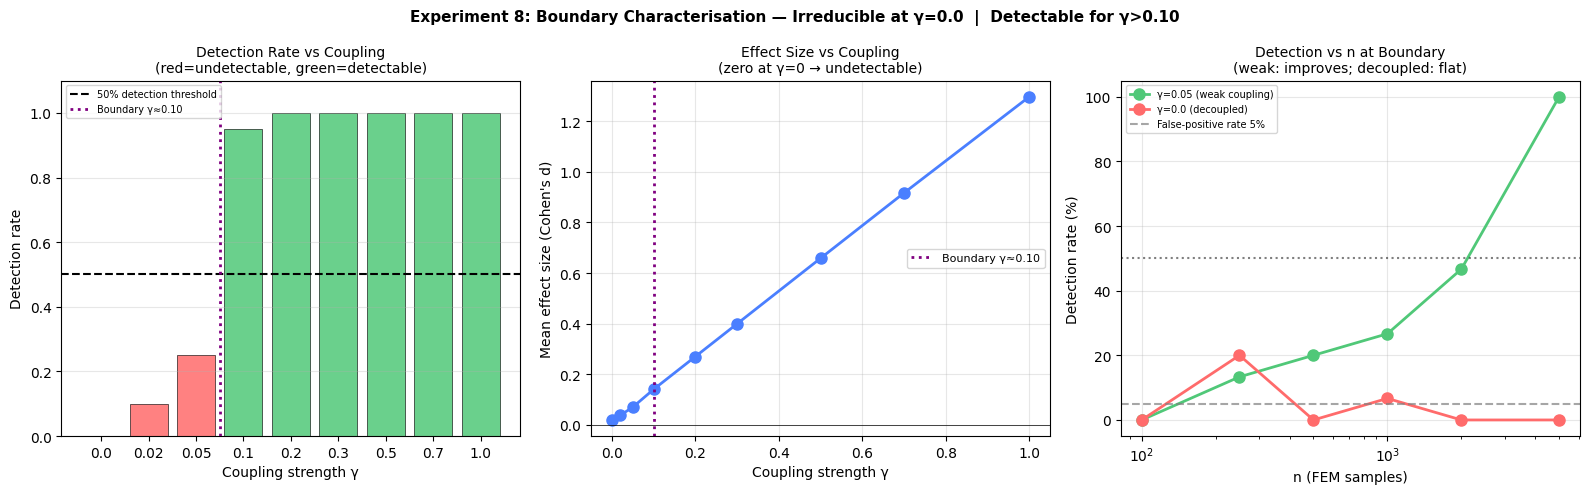

Figure saved: experiment8_boundary.png
Results saved: experiment8_results.json


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Detection rate vs coupling strength
ax = axes[0]
colors = ['#ff6b6b' if r < 0.5 else '#50c878' for r in detection_rates]
ax.bar([str(g) for g in COUPLING_STRENGTHS], detection_rates,
       color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5,
           label='50% detection threshold')
ax.axvline(x=boundary_idx - 0.5 if boundary_idx else 0.5,
           color='purple', linestyle=':', linewidth=2,
           label=f'Boundary γ≈{empirical_boundary:.2f}')
ax.set_xlabel('Coupling strength γ')
ax.set_ylabel('Detection rate')
ax.set_title('Detection Rate vs Coupling\n'
             '(red=undetectable, green=detectable)', fontsize=10)
ax.set_ylim([0, 1.1])
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Effect size vs coupling
ax = axes[1]
ax.plot(COUPLING_STRENGTHS, mean_effect_sizes, 'o-',
        color='#4a7fff', markersize=8, linewidth=2)
ax.axvline(x=empirical_boundary if boundary_idx else 0,
           color='purple', linestyle=':', linewidth=2,
           label=f'Boundary γ≈{empirical_boundary:.2f}')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Coupling strength γ')
ax.set_ylabel('Mean effect size (Cohen\'s d)')
ax.set_title('Effect Size vs Coupling\n(zero at γ=0 → undetectable)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: n-scaling at boundary
ax = axes[2]
ax.semilogx(N_VALUES_BOUND, [r*100 for r in rates_weak], 'o-',
            color='#50c878', markersize=8, linewidth=2,
            label=f'γ={GAMMA_WEAK} (weak coupling)')
ax.semilogx(N_VALUES_BOUND, [r*100 for r in rates_zero], 'o-',
            color='#ff6b6b', markersize=8, linewidth=2,
            label=f'γ={GAMMA_ZERO} (decoupled)')
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.7,
           label='False-positive rate 5%')
ax.axhline(y=50, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('n (FEM samples)')
ax.set_ylabel('Detection rate (%)')
ax.set_title('Detection vs n at Boundary\n'
             '(weak: improves; decoupled: flat)', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Experiment 8: Boundary Characterisation — '
    f'Irreducible at γ=0.0  |  Detectable for γ>{empirical_boundary:.2f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('experiment8_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: experiment8_boundary.png')

results8 = {
    'experiment': 8,
    'coupling_strengths': COUPLING_STRENGTHS,
    'detection_rates': detection_rates,
    'mean_p_values': mean_p_values,
    'mean_effect_sizes': mean_effect_sizes,
    'empirical_boundary': float(empirical_boundary) if boundary_idx else None,
    'decoupled_det_rate': float(detection_rates[0]),
    'n_scaling': {
        'n_values': N_VALUES_BOUND,
        'weak_rates': rates_weak,
        'zero_rates': rates_zero
    },
    'proposition_validated': bool(detection_rates[0] < 0.1)
}
with open('experiment8_results.json','w') as f:
    json.dump(results8, f, indent=2)
print('Results saved: experiment8_results.json')